# Feature Engeneering

## 1. Загрузка и первичный осмотр данных

Здесь мы снова читаем исходный `train.csv` и делаем первые шаги:
- смотрим форму таблицы (число строк и столбцов);
- выводим первые несколько строк, чтобы вспомнить структуру датасета;
- проверяем типы данных по умолчанию.


In [2]:
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 200)

TRAIN_PATH = "data/train.csv"   
TEST_PATH  = "data/test.csv"

df_raw = pd.read_csv(TRAIN_PATH)
print(df_raw.shape)
df_raw.head(3)

(1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500


Проверяем, все ли корректно загрузилось.  
Мы видим общий размер датасета и первые строки.  

## 2. Диагностика пропусков и типов

Перед обработкой важно понять:
- сколько всего пропусков в датасете;
- какие колонки имеют наибольшее количество пропусков;
- как распределены типы данных (числовые, категориальные).


In [3]:
def null_table(df):
    n = df.isna().sum()
    pct = (n / len(df) * 100).round(2)
    out = (
        pd.concat([n.rename("n_null"), pct.rename("%")], axis=1)
          .query("n_null > 0")
          .sort_values("n_null", ascending=False)
    )
    return out

def peek(df):
    return pd.DataFrame({
        "n_rows": [len(df)],
        "n_cols": [df.shape[1]],
        "n_null_cells": [int(df.isna().sum().sum())]
    })

peek(df_raw), null_table(df_raw).head(20)

(   n_rows  n_cols  n_null_cells
 0    1460      81          7829,
               n_null      %
 PoolQC          1453  99.52
 MiscFeature     1406  96.30
 Alley           1369  93.77
 Fence           1179  80.75
 MasVnrType       872  59.73
 FireplaceQu      690  47.26
 LotFrontage      259  17.74
 GarageType        81   5.55
 GarageYrBlt       81   5.55
 GarageFinish      81   5.55
 GarageQual        81   5.55
 GarageCond        81   5.55
 BsmtExposure      38   2.60
 BsmtFinType2      38   2.60
 BsmtQual          37   2.53
 BsmtCond          37   2.53
 BsmtFinType1      37   2.53
 MasVnrArea         8   0.55
 Electrical         1   0.07)

Здесь мы получаем **сводку по пропускам** и первые 20 проблемных колонок.  
Это поможет решить, где делать импьютацию, а где — просто удалить признак.


## 3. Удаление грубых выбросов

### 3.1 Проверка выбросов грубых выбросов

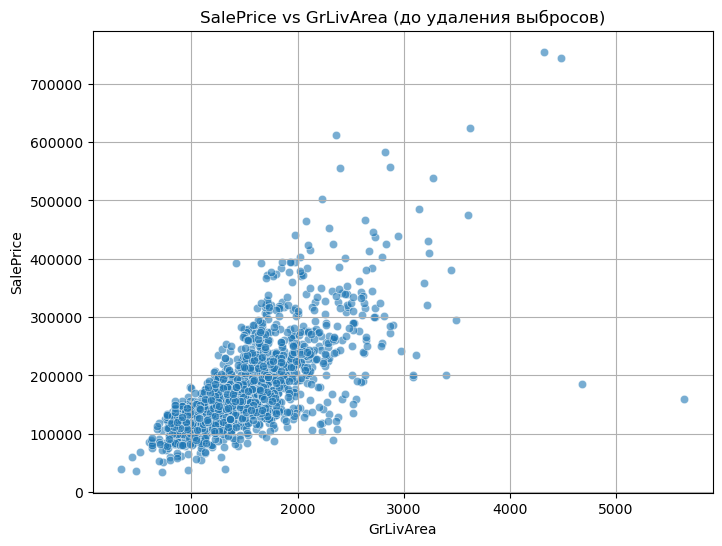

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- SalePrice vs GrLivArea ---
plt.figure(figsize=(8,6))
sns.scatterplot(x="GrLivArea", y="SalePrice", data=df_raw, alpha=0.6)
plt.title("SalePrice vs GrLivArea (до удаления выбросов)")
plt.grid()
plt.show();

Некоторые дома в датасете аномально большие или дорогие.  
Такие выбросы могут смещать обучение модели.  
Мы уберём:
- `GrLivArea > 4000`
- `SalePrice > 700000`


### 3.2 Проверка влияния на метрики моделей

Будем тестировать:  
- **Линейная регрессия**  
- **CatBoost** 

####  Хелперы для сравнения моделей  
Создаем вспомогательные функции, чтобы упростить анализ.  
*(В дальнейшем будем дополнять новыми функциями по мере продвижения.)*

In [4]:
# ---------- Импорты --------------------------------------------------------

from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector as selector
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.metrics import root_mean_squared_error, mean_absolute_percentage_error

from catboost import CatBoostRegressor, Pool
# Константы
TARGET = "SalePrice"
ID_COL = "Id"
CV_FOLDS = 5
RANDOM_STATE = 42

# -------- Препроцессор (общий), опционально скейлим числовые ----------------
def build_preprocessor(*, scale_numeric: bool = False) -> ColumnTransformer:
    num_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        num_steps.append(("scaler", StandardScaler()))
    return ColumnTransformer(
        transformers=[
            ("num", Pipeline(num_steps), selector(dtype_include=np.number)),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="constant", fill_value="NA")),
                ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False)), 
            ]), selector(dtype_exclude=np.number)),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )

# -------- Линейные модели ----------------------------------------------------
def build_linear_pipeline() -> Pipeline:
    return Pipeline([
        ("pre", build_preprocessor(scale_numeric=False)),
        ("lin", LinearRegression()),
    ])

def build_lasso_cv_pipeline(cv=CV_FOLDS, max_iter=5000, random_state=RANDOM_STATE) -> Pipeline:
    return Pipeline([
        ("pre", build_preprocessor(scale_numeric=True)),  # для Lasso скейлим числа
        ("model", LassoCV(cv=cv, random_state=random_state, max_iter=max_iter, n_jobs=-1)),
    ])

# -------- Вспомогательные для Lasso -----------------------------------------
def lasso_coeffs_df(fitted_lasso_pipe) -> pd.DataFrame:
    feat_names = fitted_lasso_pipe.named_steps["pre"].get_feature_names_out()
    coefs = fitted_lasso_pipe.named_steps["model"].coef_
    dfc = pd.DataFrame({"feature": feat_names, "coef": coefs})
    dfc["abs_coef"] = dfc["coef"].abs()
    dfc["sign"] = np.sign(dfc["coef"]).astype(int)
    return dfc.sort_values("abs_coef", ascending=False, kind="mergesort")

def lasso_group_by_raw_feature(coefs_df: pd.DataFrame) -> pd.DataFrame:
    raw = coefs_df["feature"].str.split("_", n=1, expand=True)[0]
    agg = coefs_df.assign(raw=raw).groupby("raw", as_index=False)["abs_coef"].sum()
    return agg.sort_values("abs_coef", ascending=False, kind="mergesort")

# -------- CatBoost -----------------------------------------------------------

def build_catboost(**kwargs):
    params = dict(
        loss_function="RMSE",
        depth=6,
        learning_rate=0.1,          
        iterations=500,
        l2_leaf_reg=3.0,
        random_seed=RANDOM_STATE,
        early_stopping_rounds=50,
        verbose=False,
        thread_count=3,
    )
    params.update(kwargs)
    return CatBoostRegressor(**params)

def catboost_prepare(df: pd.DataFrame) -> pd.DataFrame:
    df2 = df.copy()
    for c in ("MSSubClass", "MoSold"):
        if c in df2.columns:
            df2[c] = df2[c].astype("Int64").astype("string")
    cat_cols = df2.select_dtypes(include=["object", "category", "string"]).columns
    if len(cat_cols):
        df2[cat_cols] = df2[cat_cols].astype("string").fillna("NA")
    num_cols = [c for c in df2.columns if c not in cat_cols]
    if num_cols:
        df2[num_cols] = df2[num_cols].replace([np.inf, -np.inf], np.nan)
    return df2

def get_cat_indices(df: pd.DataFrame, drop=(TARGET, ID_COL)):
    X = df.drop(columns=[c for c in drop if c in df.columns])
    return [i for i, c in enumerate(X.columns)
            if str(X[c].dtype).startswith(("object","category","string"))]

# -------- Оценка моделей -----------------------------------------------------
def evaluate_cv(model, X, y, *, use_catboost=False, cat_features=None, cv=CV_FOLDS):
    if not use_catboost:
        scores = cross_val_score(
            model, X, y,
            cv=KFold(n_splits=cv, shuffle=False),
            scoring="neg_root_mean_squared_error"
        )
        return {"RMSE": float(-scores.mean())}
    # CatBoost — ручной цикл, чтобы передать cat_features и посчитать MAPE
    kf = KFold(n_splits=cv, shuffle=False)
    rmses, mapes = [], []
    for tr_idx, val_idx in kf.split(X):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
        train_pool = Pool(X_tr, y_tr, cat_features=cat_features)
        val_pool   = Pool(X_val, y_val, cat_features=cat_features)
        model.fit(train_pool, eval_set=val_pool)
        preds = model.predict(val_pool)
        rmses.append(root_mean_squared_error(y_val, preds))
        mapes.append(mean_absolute_percentage_error(y_val, preds))
    return {"RMSE": float(np.mean(rmses)), "MAPE": float(np.mean(mapes))}

# -------- Сравнение двух версий датасета (без внутренних масок) -------------
def _evaluate_on_df(model, df, *, use_catboost=False):
    df_work = catboost_prepare(df) if use_catboost else df.copy()
    drop_cols = [TARGET] + ([ID_COL] if ID_COL in df_work.columns else [])
    X = df_work.drop(columns=[c for c in drop_cols if c in df_work.columns])
    y = df_work[TARGET].astype(float)
    if use_catboost:
        cat_features = get_cat_indices(df_work)
        res = evaluate_cv(model, X, y, use_catboost=True, cat_features=cat_features)
    else:
        res = evaluate_cv(model, X, y, use_catboost=False)
    return {"n_objects": int(len(X)), **res}

def compare_two_datasets(model, df_A, df_B, *,
                         labels=("A_base", "B_features"),
                         use_catboost=False):
    res_A = _evaluate_on_df(model, df_A, use_catboost=use_catboost)
    res_B = _evaluate_on_df(model, df_B, use_catboost=use_catboost)
    a, b = labels
    print(f"Model: {type(model).__name__}")
    print(f"{a}: n={res_A['n_objects']}, RMSE={res_A['RMSE']:.0f}" +
          (f", MAPE={res_A.get('MAPE')*100:.2f}%" if 'MAPE' in res_A else ""))
    print(f"{b}: n={res_B['n_objects']}, RMSE={res_B['RMSE']:.0f}" +
          (f", MAPE={res_B.get('MAPE')*100:.2f}%" if 'MAPE' in res_B else ""))
    return res_A, res_B

# -------- Сравнение "все строки" vs "после очистки выбросов" ----------------

def compare_model_raw_vs_clean(model, df, *, use_catboost=False):
    """
    Сравнивает модель на одном df: (ALL) все строки vs (CLEAN) после простых порогов.
    Пороги внутри: GrLivArea<=4000, SalePrice<=700000. Под CatBoost сам делает prepare().
    Печатает RMSE (и MAPE для CatBoost). Возвращает (res_all, res_clean).
    """
    # 0) Подготовка под CatBoost при необходимости
    df_work = catboost_prepare(df) if use_catboost else df.copy()

    # 1) Разделяем на X/y
    drop_cols = [TARGET] + ([ID_COL] if ID_COL in df_work.columns else [])
    X = df_work.drop(columns=[c for c in drop_cols if c in df_work.columns])
    y = df_work[TARGET].astype(float)

    # 2) Простая маска «грубых» выбросов (правила можно править под себя)
    GRLIVAREA_MAX, SALEPRICE_MAX = 4000, 700_000
    mask = np.ones(len(df_work), dtype=bool)
    if "GrLivArea" in df_work.columns:
        mask &= (df_work["GrLivArea"] <= GRLIVAREA_MAX)
    if TARGET in df_work.columns:
        mask &= (df_work[TARGET] <= SALEPRICE_MAX)

    # 3) Оценка
    if use_catboost:
        cat_features = get_cat_indices(df_work)
        res_all   = evaluate_cv(model, X, y, use_catboost=True, cat_features=cat_features)
        res_clean = evaluate_cv(model, X.loc[mask], y.loc[mask], use_catboost=True, cat_features=cat_features)
    else:
        res_all   = evaluate_cv(model, X, y, use_catboost=False)
        res_clean = evaluate_cv(model, X.loc[mask], y.loc[mask], use_catboost=False)

    # 4) Отчёт
    print(f"Model: {type(model).__name__}")
    print(f"Всего объектов: {len(X)} | После очистки: {mask.sum()} | Удалено: {len(X)-mask.sum()}")
    print(f"RMSE (all):   {res_all['RMSE']:.0f}" + (f", MAPE={res_all.get('MAPE')*100:.2f}%" if 'MAPE' in res_all else ""))
    print(f"RMSE (clean): {res_clean['RMSE']:.0f}" + (f", MAPE={res_clean.get('MAPE')*100:.2f}%" if 'MAPE' in res_clean else ""))

    return res_all, res_clean

# === RMSLE helpers  ==============================
from sklearn.base import clone

def _rmsle_score(y_true, y_pred):
    # на всякий случай клипнем в 0, т.к. лог требует неотрицательные
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    y_true = np.maximum(y_true, 0)
    y_pred = np.maximum(y_pred, 0)
    return float(np.sqrt(np.mean((np.log1p(y_true) - np.log1p(y_pred))**2)))

def _evaluate_on_df_rmsle(model, df, *, use_catboost=False):
    """Оценивает одну модель на одном df по RMSLE (ручной KFold)."""
    df_work = catboost_prepare(df) if use_catboost else df.copy()
    drop_cols = [TARGET] + ([ID_COL] if ID_COL in df_work.columns else [])
    X = df_work.drop(columns=[c for c in drop_cols if c in df_work.columns])
    y = df_work[TARGET].astype(float)

    kf = KFold(n_splits=CV_FOLDS, shuffle=False)
    scores = []

    if use_catboost:
        # для каждого фолда создаём новый CatBoost с теми же параметрами
        params = model.get_params()
        cat_idx = get_cat_indices(df_work)
        for tr, va in kf.split(X):
            m = type(model)(**params)
            tr_pool = Pool(X.iloc[tr], y.iloc[tr], cat_features=cat_idx)
            va_pool = Pool(X.iloc[va], y.iloc[va], cat_features=cat_idx)
            m.fit(tr_pool, eval_set=va_pool, verbose=False)
            preds = m.predict(va_pool)
            scores.append(_rmsle_score(y.iloc[va].values, preds))
    else:
        for tr, va in kf.split(X):
            m = clone(model)                
            m.fit(X.iloc[tr], y.iloc[tr])
            preds = m.predict(X.iloc[va])
            scores.append(_rmsle_score(y.iloc[va].values, preds))

    return {"RMSLE": float(np.mean(scores))}

def compare_two_datasets_rmsle(model, df_A, df_B, *,
                               labels=("A_base", "B_features"),
                               use_catboost=False):
    """Сравнить две версии df по RMSLE (одни и те же фолды)."""
    res_A = _evaluate_on_df_rmsle(model, df_A, use_catboost=use_catboost)
    res_B = _evaluate_on_df_rmsle(model, df_B, use_catboost=use_catboost)

    a, b = labels
    print(f"Model: {type(model).__name__}  [metric: RMSLE]")
    print(f"{a}: RMSLE={res_A['RMSLE']:.4f}")
    print(f"{b}: RMSLE={res_B['RMSLE']:.4f}")
    delta = res_B["RMSLE"] - res_A["RMSLE"]
    print(f"ΔRMSLE ({b} - {a}) = {delta:+.4f}  ({(delta/res_A['RMSLE'])*100:+.1f}%)")

    return res_A, res_B



#### Сравниваем результаты

In [5]:
compare_model_raw_vs_clean(build_linear_pipeline(), df_raw);

Model: Pipeline
Всего объектов: 1460 | После очистки: 1456 | Удалено: 4
RMSE (all):   35399
RMSE (clean): 24984


In [39]:
compare_model_raw_vs_clean(
    build_catboost(iterations=500, learning_rate=0.1, verbose=False),
    df_raw, use_catboost=True
);

Model: CatBoostRegressor
Всего объектов: 1460 | После очистки: 1456 | Удалено: 4
RMSE (all):   25640, MAPE=8.78%
RMSE (clean): 22532, MAPE=8.59%


Несмотря на маленькое количество выбросов, модели показывают лучший результат.  

- Убираем выбросы  
- Сохраняем датасет без выбросов в новую переменную


In [6]:
df_clean = df_raw.query("GrLivArea <= 4000 and SalePrice <= 700000").copy()

## 4. Инженерия базовых признаков

Создаём новые фичи, которые лучше отражают сущность дома:
- **Возраст** (`HouseAge`, `RemodAge`, `GarageAge`);
- **Суммарные площади** (`TotalSF`, `TotalPorchSF`);
- **Общее число ванных комнат** (`TotalBath`);
- **Флаги наличия** (гараж, подвал, бассейн, камин и т.д.);
- **Взаимодействия** (`GrLivArea * OverallQual`, `GarageAreaPerCar`, `BedPerRoom`).


#### Сразу оборачиваем в функцию для последующего использования в Streamlit

In [7]:
def add_basic_features(df_in: pd.DataFrame) -> pd.DataFrame:
    df = df_in.copy()

    # Возрасты (лучше годов)
    if set(["YrSold", "YearBuilt"]).issubset(df.columns):
        df["HouseAge"] = df["YrSold"] - df["YearBuilt"]
    if set(["YrSold", "YearRemodAdd"]).issubset(df.columns):
        df["RemodAge"] = df["YrSold"] - df["YearRemodAdd"]
    if set(["YrSold", "GarageYrBlt"]).issubset(df.columns):
        df["GarageAge"] = df["YrSold"] - df["GarageYrBlt"]

    # Комбинированные площади
    def safe(col): return df[col] if col in df.columns else 0
    df["TotalSF"] = safe("TotalBsmtSF") + safe("1stFlrSF") + safe("2ndFlrSF")
    df["TotalPorchSF"] = safe("OpenPorchSF") + safe("3SsnPorch") + safe("EnclosedPorch") + safe("ScreenPorch") + safe("WoodDeckSF")

    # Ванные (полные + половинные)
    df["TotalBath"] = (
        (safe("FullBath") + 0.5*safe("HalfBath")) +
        (safe("BsmtFullBath") + 0.5*safe("BsmtHalfBath"))
    )

    # Флаги наличия
    if "TotalBsmtSF" in df.columns:
        df["HasBasement"] = (df["TotalBsmtSF"] > 0).astype("int8")
    if "GarageArea" in df.columns:
        df["HasGarage"] = (df["GarageArea"] > 0).astype("int8")
    for col, flag in [("PoolQC", "HasPool"), ("Alley", "HasAlley"), ("Fence", "HasFence"), ("FireplaceQu", "HasFireplace")]:
        if col in df.columns:
            df[flag] = (~df[col].isna()).astype("int8")

    # Приведение MSSubClass к строке (категория)
    if "MSSubClass" in df.columns and not pd.api.types.is_string_dtype(df["MSSubClass"]):
        df["MSSubClass"] = df["MSSubClass"].astype(str)

    # Взаимодействия / соотношения
    if {"GrLivArea", "OverallQual"}.issubset(df.columns):
        df["GrLivArea_x_Qual"] = df["GrLivArea"] * df["OverallQual"]

    if {"GarageArea", "GarageCars"}.issubset(df.columns):
        # средняя площадь на машину; избегаем деления на 0
        df["GarageAreaPerCar"] = df["GarageArea"] / df["GarageCars"].replace({0: np.nan})
        df["GarageAreaPerCar"] = df["GarageAreaPerCar"].fillna(0)

    if {"BedroomAbvGr", "TotRmsAbvGrd"}.issubset(df.columns):
        df["BedPerRoom"] = df["BedroomAbvGr"] / df["TotRmsAbvGrd"].replace({0: np.nan})
        df["BedPerRoom"] = df["BedPerRoom"].fillna(0)

    return df

df_clean_fe = add_basic_features(df_clean)
peek(df_clean_fe), df_clean_fe.filter(regex="Age|Total|Has|Per|x_Qual").head(3)


(   n_rows  n_cols  n_null_cells
 0    1456      96          7896,
    TotalBsmtSF  HouseAge  RemodAge  GarageAge  TotalSF  TotalPorchSF  \
 0          856         5         5        5.0     2566            61   
 1         1262        31        31       31.0     2524           298   
 2          920         7         6        7.0     2706            42   
 
    TotalBath  HasBasement  HasGarage  HasPool  HasAlley  HasFence  \
 0        3.5            1          1        0         0         0   
 1        2.5            1          1        0         0         0   
 2        3.5            1          1        0         0         0   
 
    HasFireplace  GrLivArea_x_Qual  GarageAreaPerCar  BedPerRoom  
 0             0             11970             274.0       0.375  
 1             1              7572             230.0       0.500  
 2             1             12502             304.0       0.500  )

#### Беглое сравнение сырого датасета с датасетом после добавления новых фичей

In [8]:
compare_two_datasets(
    build_linear_pipeline(),
    df_clean, df_clean_fe,
    labels=("clean_baseline", "clean + features"),
    use_catboost=False
);


Model: Pipeline
clean_baseline: n=1456, RMSE=24984
clean + features: n=1456, RMSE=23902


In [43]:
compare_two_datasets(
    build_catboost(iterations=500, learning_rate=0.1, early_stopping_rounds=50),
    df_clean, df_clean_fe,
    labels=("clean_baseline", "clean + features"),
    use_catboost=True
);

Model: CatBoostRegressor
clean_baseline: n=1456, RMSE=22532, MAPE=8.59%
clean + features: n=1456, RMSE=22029, MAPE=8.47%


In [9]:
compare_two_datasets(
    build_lasso_cv_pipeline(cv=5),
    df_clean, df_clean_fe,
    labels=("clean", "clean + features"),
    use_catboost=False
);

Model: Pipeline
clean: n=1456, RMSE=23123
clean + features: n=1456, RMSE=21492


Метрики немного улучшились  
Оставляем фичи, возможно они станут более значимыми после удаления ненужных колонок

## 5. Группировка районов по средней цене

Признак `Neighborhood` очень сильный, но содержит много категорий.  
Чтобы уменьшить шум, группируем районы в **4 квантили** по средней цене домов.


In [10]:
def make_neighborhood_group(df_in: pd.DataFrame, n_groups: int = 4):
    if not {"Neighborhood", "SalePrice"}.issubset(df_in.columns):
        return None  # нечего делать
    gp = df_in.groupby("Neighborhood")["SalePrice"].mean().sort_values()
    # разбиваем районы по квантилям средней цены
    edges = pd.qcut(gp, q=n_groups, retbins=True, duplicates="drop")[1]
    # строим функцию бининга по средним
    def to_group(mean_price):
        # правая включительность как в qcut
        idx = np.searchsorted(edges, mean_price, side="right") - 1
        idx = np.clip(idx, 0, len(edges)-2)
        return int(idx)
    mapping = {neigh: to_group(mean) for neigh, mean in gp.items()}
    return mapping

neigh_map = make_neighborhood_group(df_clean_fe, n_groups=4)
if neigh_map is not None:
    df_clean_fe["NeighborhoodGroup"] = df_clean_fe["Neighborhood"].map(neigh_map).astype("Int64")
    print("Neighborhood groups created:", pd.Series(df_clean_fe["NeighborhoodGroup"]).unique())
else:
    print("Neighborhood grouping skipped (no columns).")

df_clean_fe[["Neighborhood","NeighborhoodGroup"]].head(8)


Neighborhood groups created: <IntegerArray>
[2, 3, 1, 0]
Length: 4, dtype: Int64


,Neighborhood,NeighborhoodGroup
0,CollgCr,2
1,Veenker,3
2,CollgCr,2
3,Crawfor,2
4,NoRidge,3
5,Mitchel,1
6,Somerst,3
7,NWAmes,2


Теперь каждый район заменяется на группу: `0` (дешёвые), `1` (средние), `2` (выше среднего), `3` (дорогие).  
Это уменьшает количество категорий и облегчает обучение.

## 6. Схлопывание редких категорий

В некоторых колонках встречаются категории с очень малым количеством объектов.  
Их лучше объединить в группу `"Rare"`, чтобы модель не переобучалась.


In [11]:
from collections import Counter

def collapse_rare_cats(df_in: pd.DataFrame, cols: list[str], min_count: int = 25, other_label: str = "Rare"):
    df = df_in.copy()
    for c in cols:
        if c not in df.columns:
            continue
        if not pd.api.types.is_object_dtype(df[c]) and not pd.api.types.is_categorical_dtype(df[c]):
            continue
        counts = Counter(df[c].fillna("__NA__"))
        rare_values = {k for k, v in counts.items() if v < min_count}
        df[c] = df[c].where(~df[c].isin(rare_values), other_label)
    return df

cat_cols = df_clean_fe.select_dtypes(include="object").columns.tolist()
# можно сузить список: например, только те, где >15 уникальных значений
wide_cats = [c for c in cat_cols if df_clean_fe[c].nunique(dropna=True) > 15]
df_clean_fe = collapse_rare_cats(df_clean_fe, wide_cats, min_count=25, other_label="Rare")

df_clean_fe[wide_cats].nunique().sort_values(ascending=False).head(10)


Neighborhood    20
Exterior2nd     10
dtype: int64

Мы оставляем только достаточно популярные категории, а редкие значения объединяем.  
Так снижается шум от «одиночных» районов или материалов.


## 7. Удаление слабых и дублирующих признаков

Некоторые признаки:
- почти константные (`Street`, `Utilities`);
- сильно дублируют друг друга (`GarageArea` vs `GarageCars`);
- мы уже преобразовали их в новые фичи (`YearBuilt` → `HouseAge`).

Их можно безопасно удалить.

In [12]:
drop_candidates = []

# Почти константы
for c in ["Street", "Utilities"]:
    if c in df_clean_fe.columns and df_clean_fe[c].nunique(dropna=True) <= 2:
        drop_candidates.append(c)

# Явные дубликаты по смыслу (оставим одни из пары)
pairs = [
    ("GarageArea", "GarageCars"),     # часто дублируют мощно
    ("TotRmsAbvGrd", "GrLivArea"),    # количество комнат ~ площадь
]
for a,b in pairs:
    if a in df_clean_fe.columns and b in df_clean_fe.columns:
        # оставим тот, кто сильнее коррелирует с SalePrice (если есть)
        if "SalePrice" in df_clean_fe.columns:
            corr_a = df_clean_fe[[a,"SalePrice"]].corr().iloc[0,1]
            corr_b = df_clean_fe[[b,"SalePrice"]].corr().iloc[0,1]
            drop = a if abs(corr_a) < abs(corr_b) else b
        else:
            drop = b  # дефолт
        drop_candidates.append(drop)

# Редкие “описательные” поля (часто пустые): переведены во флаги в Cell 4 — исходники можно убрать
for c in ["PoolQC","Alley","Fence","FireplaceQu"]:
    if c in df_clean_fe.columns:
        drop_candidates.append(c)

# Дублирующие "годы" после появления Age-фич
for c in ["YearBuilt","YearRemodAdd","GarageYrBlt","YrSold"]:
    if c in df_clean_fe.columns and c.replace("Year","") != "GarageYrBlt":
        drop_candidates.append(c)

drop_candidates = sorted(set([c for c in drop_candidates if c in df_clean_fe.columns and c != "SalePrice" and c != "Id"]))
print(f"To drop ({len(drop_candidates)}):", drop_candidates[:20], "..." if len(drop_candidates)>20 else "")

df_clean_fe = df_clean_fe.drop(columns=drop_candidates)
peek(df_clean_fe)
df_clean_fe.head(3)


To drop (11): ['Alley', 'Fence', 'FireplaceQu', 'GarageArea', 'PoolQC', 'Street', 'TotRmsAbvGrd', 'Utilities', 'YearBuilt', 'YearRemodAdd', 'YrSold'] 


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,LotShape,LandContour,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,Functional,Fireplaces,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscFeature,MiscVal,MoSold,SaleType,SaleCondition,SalePrice,HouseAge,RemodAge,GarageAge,TotalSF,TotalPorchSF,TotalBath,HasBasement,HasGarage,HasPool,HasAlley,HasFence,HasFireplace,GrLivArea_x_Qual,GarageAreaPerCar,BedPerRoom,NeighborhoodGroup
0,1,60,RL,65.0,8450,Reg,Lvl,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,Typ,0,Attchd,2003.0,RFn,2,TA,TA,Y,0,61,0,0,0,0,NaN,0,2,WD,Normal,208500,5,5,5.0,2566,61,3.5,1,1,0,0,0,0,11970,274.0,0.375,2
1,2,20,RL,80.0,9600,Reg,Lvl,FR2,Gtl,Rare,Feedr,Norm,1Fam,1Story,6,8,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,Typ,1,Attchd,1976.0,RFn,2,TA,TA,Y,298,0,0,0,0,0,NaN,0,5,WD,Normal,181500,31,31,31.0,2524,298,2.5,1,1,0,0,0,1,7572,230.0,0.500,3
2,3,60,RL,68.0,11250,IR1,Lvl,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,Typ,1,Attchd,2001.0,RFn,2,TA,TA,Y,0,42,0,0,0,0,NaN,0,9,WD,Normal,223500,7,6,7.0,2706,42,3.5,1,1,0,0,0,1,12502,304.0,0.500,2


## 8. Финальный датасет: X и y

Теперь разделяем данные на признаки (`X`) и целевую переменную (`y`).  
Целевую переменную логарифмируем (`log1p`), чтобы сгладить хвост распределения.


In [13]:
assert "SalePrice" in df_clean_fe.columns, "В данных нет 'SalePrice'. Проверь загрузку train."
X_fe = df_clean_fe.drop(columns=["SalePrice", "Id"], errors="ignore")
y_fe = np.log1p(df_clean_fe["SalePrice"])  # устойчивый лог-таргет

X_fe.shape, y_fe.shape


((1456, 84), (1456,))

## 9. Применение тех же правил к тесту

Чтобы не было утечек, на `test.csv` применяем **те же функции и маппинги**, что и для train:
- добавляем те же признаки,
- группируем `Neighborhood` по train-mapping,
- схлопываем редкие категории,
- удаляем те же колонки.


In [14]:
df_test_raw = pd.read_csv(TEST_PATH)

# 1) (опционально) фильтр выбросов для test чаще НЕ делают — оставим как есть
df_test = df_test_raw.copy()

# 2) те же базовые фичи
df_test = add_basic_features(df_test)

# 3) те же групповые признаки по train-mapping
if ("Neighborhood" in df_test.columns) and (neigh_map is not None):
    df_test["NeighborhoodGroup"] = df_test["Neighborhood"].map(neigh_map).astype("Int64")

# 4) те же схлопывания редких категорий — используем столбцы из train
test_wide = [c for c in wide_cats if c in df_test.columns]
df_test = collapse_rare_cats(df_test, test_wide, min_count=25, other_label="Rare")

# 5) те же колонки удаляем
df_test = df_test.drop(columns=[c for c in drop_candidates if c in df_test.columns], errors="ignore")

# 6) финальные фичи для модели
X_test_fe = df_test.drop(columns=["Id"], errors="ignore")
print("Train FE shape:", X_fe.shape, " | Test FE shape:", X_test_fe.shape)
X_test_fe.head(3)


Train FE shape: (1456, 84)  | Test FE shape: (1459, 84)


,MSSubClass,MSZoning,LotFrontage,LotArea,LotShape,LandContour,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,Functional,Fireplaces,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscFeature,MiscVal,MoSold,SaleType,SaleCondition,HouseAge,RemodAge,GarageAge,TotalSF,TotalPorchSF,TotalBath,HasBasement,HasGarage,HasPool,HasAlley,HasFence,HasFireplace,GrLivArea_x_Qual,GarageAreaPerCar,BedPerRoom,NeighborhoodGroup
0,20,RH,80.0,11622,Reg,Lvl,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,Typ,0,Attchd,1961.0,Unf,1.0,TA,TA,Y,140,0,0,0,120,0,NaN,0,6,WD,Normal,49,49,49.0,1778.0,260,1.0,1,1,0,0,1,0,4480,730.0,0.4,1
1,20,RL,81.0,14267,IR1,Lvl,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,Typ,0,Attchd,1958.0,Unf,1.0,TA,TA,Y,393,36,0,0,0,0,Gar2,12500,6,WD,Normal,52,52,52.0,2658.0,429,1.5,1,1,0,0,0,0,7974,312.0,0.5,1
2,60,RL,74.0,13830,IR1,Lvl,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,Typ,1,Attchd,1997.0,Fin,2.0,TA,TA,Y,212,34,0,0,0,0,NaN,0,3,WD,Normal,13,12,13.0,2557.0,246,2.5,1,1,0,0,1,1,8145,241.0,0.5,2


Теперь `X_test_fe` имеет ту же структуру, что и `X_fe` из train, и готов к подаче в модель.


## 10. Собираем модель для подбора параметров в **Optuna**

### 10.1 Собираем таблицы 

In [15]:
# Собираем train-таблицу из X_fe и y_fe (y_fe уже в лог-пространстве)
df_train = X_fe.copy()
df_train[TARGET] = y_fe

# Подготовка под CatBoost (строки для категориальных, NA и т.п.)
df_train_cb = catboost_prepare(df_train)

# Разделяем на X / y
drop_cols = [TARGET] + ([ID_COL] if ID_COL in df_train_cb.columns else [])
X_cb = df_train_cb.drop(columns=[c for c in drop_cols if c in df_train_cb.columns])
y_cb = df_train_cb[TARGET].astype(float)

# Индексы категориальных фичей 
cat_idx = get_cat_indices(df_train_cb)
len(X_cb), len(y_cb), len(cat_idx)



(1456, 1456, 39)

### 10.2 Задаем параметры для **Optuna**

In [16]:
from sklearn.model_selection import RepeatedKFold
import optuna
from catboost import Pool


N_SPLITS = 3    # CV_FOLDS=5

def objective(trial: optuna.Trial) -> float:
    params = dict(
        
        iterations      = trial.suggest_int("iterations", 600, 2000),
        depth           = trial.suggest_int("depth", 4, 8),
        learning_rate   = trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        l2_leaf_reg     = trial.suggest_float("l2_leaf_reg", 1.0, 20.0, log=True),

        random_strength     = trial.suggest_float("random_strength", 0.0, 2.0),
        bagging_temperature = trial.suggest_float("bagging_temperature", 0.0, 1.0),

        grow_policy     = trial.suggest_categorical("grow_policy", ["SymmetricTree","Depthwise","Lossguide"]),
        border_count    = trial.suggest_int("border_count", 128, 254),

        loss_function   = "RMSE",            
        random_seed     = RANDOM_STATE,
        verbose         = False,
        early_stopping_rounds = 50,
    )

    rkf = KFold(n_splits=N_SPLITS, shuffle=True)
    rmses = []

    # ВАЖНО: cat_idx берём из (get_cat_indices(df_train_cb))
    for step, (tr_idx, va_idx) in enumerate(rkf.split(X_cb), start=1):
        m = build_catboost(**params)
        tr_pool = Pool(X_cb.iloc[tr_idx], y_cb.iloc[tr_idx], cat_features=cat_idx)
        va_pool = Pool(X_cb.iloc[va_idx], y_cb.iloc[va_idx], cat_features=cat_idx)
        m.fit(tr_pool, eval_set=va_pool)
        preds = m.predict(va_pool)
        rmse  = root_mean_squared_error(y_cb.iloc[va_idx], preds) 
        rmses.append(rmse)

        # Отчитываемся Optuna по ходу, чтобы работал pruner
        trial.report(float(np.mean(rmses)), step)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return float(np.mean(rmses))  # минимизируем средний RMSE по всем фолдам и повторам


### 10.3 Запускаем **Optuna**  
- Создаем `sampler` для умного выбора парметров
- `pruner` — для возможной ранней остановки

In [23]:
sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE, multivariate=True)
pruner  = optuna.pruners.MedianPruner(n_warmup_steps=5)

study = optuna.create_study(direction="minimize", sampler=sampler, pruner=pruner)
study.optimize(objective, n_trials=30, n_jobs=3, show_progress_bar=True)

print(f"Best RMSE (log-space): {study.best_value:.6f}")
print("Best params:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")


c:\Users\user\miniforge3\envs\eda_env\Lib\site-packages\optuna\_experimental.py:32: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  warnings.warn(
[I 2025-08-29 13:53:25,278] A new study created in memory with name: no-name-91b70ec2-c05b-4905-9c5a-b50848f45d28


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-08-29 13:54:18,774] Trial 2 finished with value: 0.1155805933600182 and parameters: {'iterations': 608, 'depth': 5, 'learning_rate': 0.11298683128611006, 'l2_leaf_reg': 1.758806174371932, 'random_strength': 1.8334310934792426, 'bagging_temperature': 0.7485748370671191, 'grow_policy': 'SymmetricTree', 'border_count': 208}. Best is trial 2 with value: 0.1155805933600182.
[I 2025-08-29 13:57:37,651] Trial 0 finished with value: 0.119839594316781 and parameters: {'iterations': 802, 'depth': 7, 'learning_rate': 0.19486319780900924, 'l2_leaf_reg': 14.436370294954468, 'random_strength': 1.5619805513432528, 'bagging_temperature': 0.5183666666009621, 'grow_policy': 'Lossguide', 'border_count': 161}. Best is trial 2 with value: 0.1155805933600182.
[I 2025-08-29 13:58:07,953] Trial 1 finished with value: 0.12108939269409331 and parameters: {'iterations': 875, 'depth': 8, 'learning_rate': 0.016146528608432815, 'l2_leaf_reg': 1.1704348572307013, 'random_strength': 1.731455956819903, 'baggin

Получаем лучшие параметры для модели, для финального перобучения

### 10.4 Финальные шаги  
- Переобучаем модель с подобранными параметрами
- Считаем таргет на тестовом датасете
- Записываем в новый файл для последующей загрузки на **Kaggle**

In [24]:
from catboost import Pool

best_cb = build_catboost(**study.best_params)

# Пулы для обучения и инференса
train_pool = Pool(X_cb, y_cb, cat_features=cat_idx)

# Подготовка теста тем же способом
X_test_cb = catboost_prepare(X_test_fe)
test_pool  = Pool(X_test_cb, cat_features=get_cat_indices(X_test_cb))

best_cb.fit(train_pool, verbose=False)

# Предсказания в лог-пространстве → переводим в цены
test_pred_log = best_cb.predict(test_pool)
test_price    = np.expm1(test_pred_log)

# Формируем submission: Id строго из исходного теста (как в sample_submission)
sub = pd.DataFrame({
    ID_COL: df_test[ID_COL].astype(int).values,
    TARGET: test_price.astype(float)
}).sort_values(ID_COL).reset_index(drop=True)

display(sub.head(), sub.tail())
sub.to_csv("submission_catboost_optuna_long.csv", index=False)
print("Saved -> submission_catboost_optuna_long.csv")


,Id,SalePrice
0,1461,113377.222349
1,1462,164272.192236
2,1463,182798.287880
3,1464,194745.503039
4,1465,188418.874968


,Id,SalePrice
1454,2915,83995.719328
1455,2916,83453.069111
1456,2917,151767.510674
1457,2918,116736.864210
1458,2919,208893.678369


Saved -> submission_catboost_optuna_long.csv


Проверяем, совпадает ли полученнный датасет с `sample_submission`

### Прогресс с метрикой на **Kaggle** за весь проект

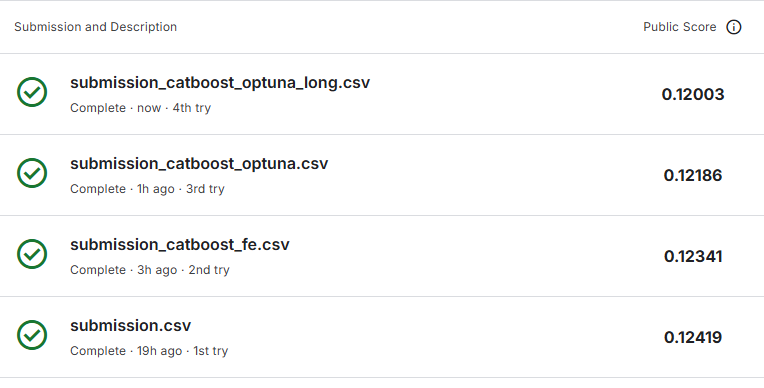

## Дополнение  
### Отчет feature_importance для финальной модели **CatBoost**

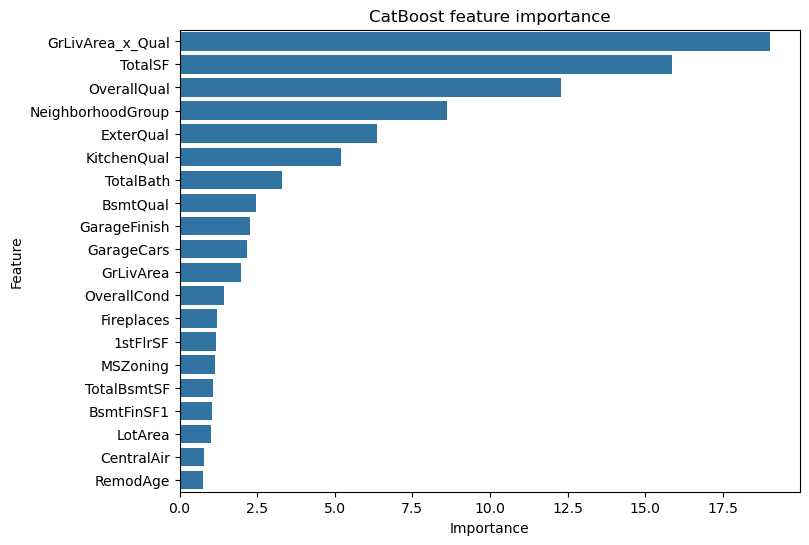

In [26]:
feat_importances = pd.Series(best_cb.feature_importances_, index=X_cb.columns)
top_feats = feat_importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(8,6))
sns.barplot(x=top_feats.values, y=top_feats.index)
plt.title("CatBoost feature importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

По значимости наши добавленные фичи высоки для модели  
**Успех :)**

### График валидации

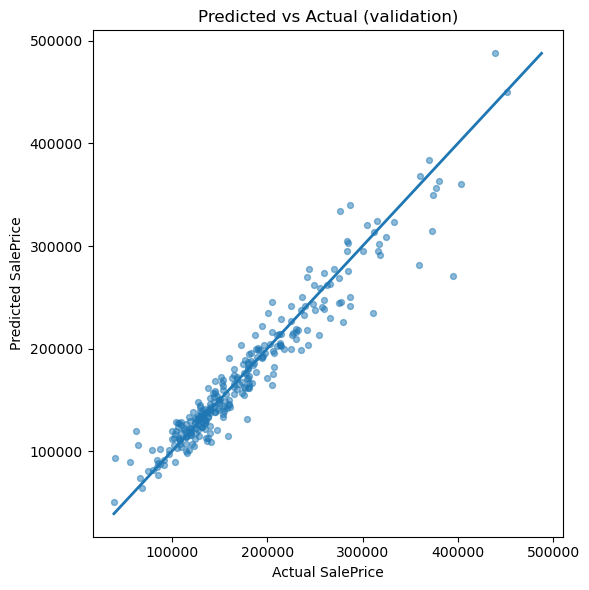

In [ ]:
from sklearn.model_selection import train_test_split


# Возьмём валидационный сплит только для графиков
X_tr, X_va, y_tr, y_va = train_test_split(X_cb, y_cb, test_size=0.2, random_state=42)
m = build_catboost(**study.best_params)
m.fit(Pool(X_tr, y_tr, cat_features=cat_idx), eval_set=Pool(X_va, y_va, cat_features=cat_idx), verbose=False)

pred_log = m.predict(X_va)
y_true  = np.expm1(y_va)
y_pred  = np.expm1(pred_log)

plt.figure(figsize=(6,6))
plt.scatter(y_true, y_pred, alpha=0.5, s=18)
lim = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
plt.plot(lim, lim, lw=2)
plt.xlabel("Actual SalePrice"); plt.ylabel("Predicted SalePrice")
plt.title("Predicted vs Actual")
plt.tight_layout()
plt.show()


### Permutation Importance

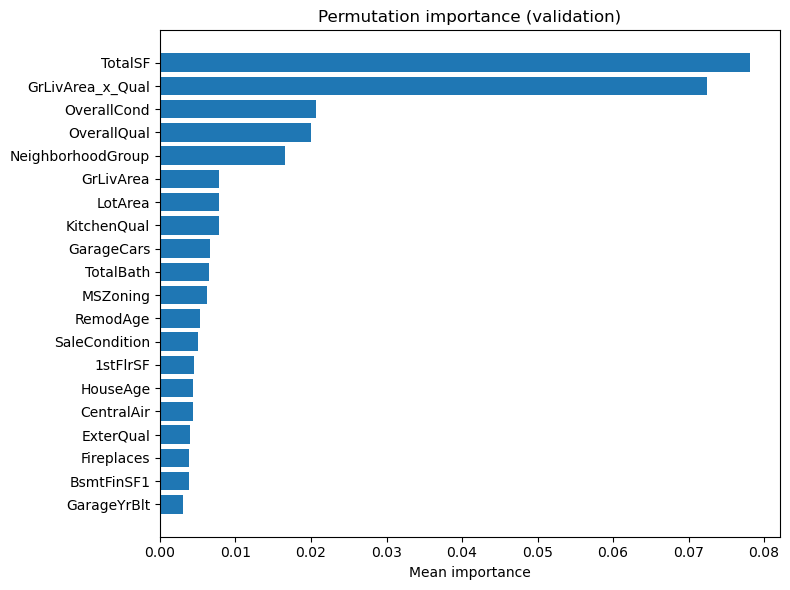

In [ ]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(m, X_va, y_va, n_repeats=10, random_state=RANDOM_STATE)
perm_df = pd.DataFrame({"feature": X_va.columns, "importance": perm.importances_mean}) \
            .sort_values("importance", ascending=False)

top = perm_df.head(20)
plt.figure(figsize=(8,6))
plt.barh(top["feature"][::-1], top["importance"][::-1])
plt.title("Permutation importance"); plt.xlabel("Mean importance")
plt.tight_layout(); plt.show()


### Средние метрики по CV

In [35]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error


kf = KFold(n_splits=CV_FOLDS, shuffle=False)
rmse_list, mae_list, r2_list, rmsle_list = [], [], [], []

for tr_idx, va_idx in kf.split(X_cb):
    X_tr, X_va = X_cb.iloc[tr_idx], X_cb.iloc[va_idx]
    y_tr, y_va = y_cb.iloc[tr_idx], y_cb.iloc[va_idx]

    mm = build_catboost(**study.best_params)
    mm.fit(Pool(X_tr, y_tr, cat_features=cat_idx), eval_set=Pool(X_va, y_va, cat_features=cat_idx), verbose=False)

    pred_log = mm.predict(X_va)
    y_true   = np.expm1(y_va)
    y_hat    = np.expm1(pred_log)

    rmse_list.append(root_mean_squared_error(y_true, y_hat))  
    mae_list.append(mean_absolute_error(y_true, y_hat))
    r2_list.append(r2_score(y_true, y_hat))
    rmsle_list.append(np.sqrt(np.mean((np.log1p(y_hat) - np.log1p(y_true))**2)))

metrics_df = pd.DataFrame({
    "RMSE":  [np.mean(rmse_list)],
    "MAE":   [np.mean(mae_list)],
    "R2":    [np.mean(r2_list)],
    "RMSLE": [np.mean(rmsle_list)],
}, index=["CatBoost (Optuna)"])

display(metrics_df.round(4))


,RMSE,MAE,R2,RMSLE
CatBoost (Optuna),20739.6527,13412.4003,0.9262,0.1123


# Чейзим ачивку

In [18]:
ID_COL = "Id"
TARGET = "SalePrice"

a = pd.read_csv("submission_catboost_optuna.csv")
b = pd.read_csv("submission_catboost_optuna_long.csv")

# Склеиваем по Id и получаем две колонки: SalePrice_a и SalePrice_b
sub = a.merge(b, on=ID_COL, how="inner", suffixes=("_a", "_b"))

# Проверим, что всё на месте
assert TARGET+"_a" in sub.columns and TARGET+"_b" in sub.columns, sub.columns.tolist()

# Геометрическое среднее (усреднение в логах) с весами 0.6/0.4
w1, w2 = 0.6, 0.4
log_blend = w1*np.log1p(sub[TARGET+"_a"]) + w2*np.log1p(sub[TARGET+"_b"])
blend_price = np.expm1(log_blend)

# (опционально) подрежем хвосты
blend_price = np.clip(blend_price, 30000, 700000)

final = pd.DataFrame({ID_COL: sub[ID_COL].astype(int), TARGET: blend_price.astype(float)})
final.to_csv("submission_blend_geo_60_40.csv", index=False, float_format="%.6f")
print("Saved -> submission_blend_geo_60_40.csv")



Saved -> submission_blend_geo_60_40.csv


Плохо, не работает

In [19]:
# === Cell: add log1p features for skewed numerics ===========================
import numpy as np
import pandas as pd

# 1) кандидаты: только числовые, без таргета и Id
num_cols = X_fe.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in {TARGET, ID_COL}]

# 2) считаем асимметрию на train (по нему же и выбираем)
skews = X_fe[num_cols].apply(lambda s: s.dropna().skew()).sort_values(ascending=False)

# 3) берём сильно скошенные |skew| >= 0.75 и только неотрицательные (log1p-требование)
THRESH = 0.75
skewed_cols = [
    c for c in skews.index
    if abs(skews[c]) >= THRESH
    and (X_fe[c].min() >= 0)
    and (c in X_test_fe.columns and X_test_fe[c].min() >= 0)
]

print(f"Найдено скошенных признаков: {len(skewed_cols)}")
print(skews.loc[skewed_cols].head(20))

# 4) создаём новые колонки *_log1p (не трогаем исходные)
for c in skewed_cols:
    newc = f"{c}_log1p"
    if newc in X_fe.columns:
        # на случай повторного запуска
        continue
    X_fe[newc]       = np.log1p(X_fe[c])
    X_test_fe[newc]  = np.log1p(X_test_fe[c])

print("Готово. Добавлены лог-фичи:", [f"{c}_log1p" for c in skewed_cols][:10], "...")


Найдено скошенных признаков: 25
MiscVal             24.443364
PoolArea            17.522613
HasPool             16.994068
LotArea             12.587561
3SsnPorch           10.289866
LowQualFinSF         8.998564
KitchenAbvGr         4.481366
BsmtFinSF2           4.248587
BsmtHalfBath         4.128967
ScreenPorch          4.115641
HasAlley             3.618513
EnclosedPorch        3.084454
MasVnrArea           2.648987
OpenPorchSF          2.339846
HasFence             1.563051
WoodDeckSF           1.551271
LotFrontage          1.536435
GrLivArea_x_Qual     1.174450
TotalPorchSF         1.108114
BsmtUnfSF            0.921759
dtype: float64
Готово. Добавлены лог-фичи: ['MiscVal_log1p', 'PoolArea_log1p', 'HasPool_log1p', 'LotArea_log1p', '3SsnPorch_log1p', 'LowQualFinSF_log1p', 'KitchenAbvGr_log1p', 'BsmtFinSF2_log1p', 'BsmtHalfBath_log1p', 'ScreenPorch_log1p'] ...


In [20]:
# Собираем train-таблицу из обновлённых X_fe / y_fe (y_fe уже лог-таргет)
df_train = X_fe.copy()
df_train[TARGET] = y_fe

# Подготовка под CatBoost
df_train_cb = catboost_prepare(df_train)

# X / y и cat_indices
drop_cols = [TARGET] + ([ID_COL] if ID_COL in df_train_cb.columns else [])
X_cb = df_train_cb.drop(columns=[c for c in drop_cols if c in df_train_cb.columns])
y_cb = df_train_cb[TARGET].astype(float)
cat_idx = get_cat_indices(df_train_cb)

len(X_cb), len(y_cb), len(cat_idx)


(1456, 1456, 39)

In [21]:
# Берём лучшие параметры из Optuna, либо зафиксируй словарь вручную
best_params = study.best_params if 'study' in globals() else {
    "iterations": 1994,
    "depth": 4,
    "learning_rate": 0.012474090404109349,
    "l2_leaf_reg": 1.0044868504320514,
    "random_strength": 1.9755895023792804,
    "bagging_temperature": 0.9959613574979078,
    "border_count": 237,
    "loss_function": "RMSE",
    "early_stopping_rounds": 50,
    "random_seed": RANDOM_STATE,
    "verbose": False,
}

cb = build_catboost(**best_params)

# Твой хелпер: RMSE (в лог-пространстве) + MAPE (для справки)
cv_res = evaluate_cv(cb, X_cb, y_cb, use_catboost=True, cat_features=cat_idx, cv=CV_FOLDS)
print(f"CV (log-space) → RMSE={cv_res['RMSE']:.6f}" + (f", MAPE={cv_res.get('MAPE')*100:.2f}%" if 'MAPE' in cv_res else ""))


CV (log-space) → RMSE=0.113410, MAPE=0.66%


In [23]:
from catboost import Pool
# Пересобираем пулы
train_pool = Pool(X_cb, y_cb, cat_features=cat_idx)

# Тест под CatBoost тем же пайпом
X_test_cb = catboost_prepare(X_test_fe)
test_pool  = Pool(X_test_cb, cat_features=get_cat_indices(X_test_cb))

# Фит и предикт
cb_final = build_catboost(**best_params)
cb_final.fit(train_pool, verbose=False)

pred_log = cb_final.predict(test_pool)   # в лог-пространстве
pred_price = np.expm1(pred_log)          # обратно в цены

# Сабмит: Id обязательно из исходного test_df
sub = pd.DataFrame({
    ID_COL: df_test[ID_COL].astype(int).values,
    TARGET: pred_price.astype(float)
}).sort_values(ID_COL).reset_index(drop=True)

display(sub.head(), sub.tail())
sub.to_csv("submission_catboost_fe_refit.csv", index=False, float_format="%.6f")
print("Saved -> submission_catboost_fe_refit.csv")


,Id,SalePrice
0,1461,116811.535352
1,1462,160495.836769
2,1463,177593.687826
3,1464,190699.565798
4,1465,190423.991719


,Id,SalePrice
1454,2915,82706.336780
1455,2916,82119.324690
1456,2917,151648.825581
1457,2918,119320.610692
1458,2919,211276.334003


Saved -> submission_catboost_fe_refit.csv


In [24]:
# === Seed-bagging for CatBoost ==============================================
import numpy as np
import pandas as pd
from catboost import Pool

# 0) Подготовка train/test под CatBoost (если уже делал выше — можно переиспользовать)
df_train = X_fe.copy()
df_train[TARGET] = y_fe
df_train_cb = catboost_prepare(df_train)

drop_cols = [TARGET] + ([ID_COL] if ID_COL in df_train_cb.columns else [])
X_cb = df_train_cb.drop(columns=[c for c in drop_cols if c in df_train_cb.columns])
y_cb = df_train_cb[TARGET].astype(float)
cat_idx = get_cat_indices(df_train_cb)

X_test_cb = catboost_prepare(X_test_fe)

train_pool = Pool(X_cb, y_cb, cat_features=cat_idx)
test_pool  = Pool(X_test_cb, cat_features=get_cat_indices(X_test_cb))

# 1) Лучшие параметры (из Optuna или зафиксируй руками)
best_params = study.best_params if 'study' in globals() else {
    "iterations": 1994,
    "depth": 4,
    "learning_rate": 0.012474090404109349,
    "l2_leaf_reg": 1.0044868504320514,
    "random_strength": 1.9755895023792804,
    "bagging_temperature": 0.9959613574979078,
    "border_count": 237,
    "loss_function": "RMSE",
    "early_stopping_rounds": 50,
    "random_seed": RANDOM_STATE,
    "verbose": False,
    "thread_count": 2  # если запускаешь много сидов параллельно
}

# 2) Набор сидов (начни с 5; если ок — расширь до 8–10)
SEEDS = [11, 22, 33, 44, 55, 69, 1337, 622]

preds_log = []
for s in SEEDS:
    params = {**best_params, "random_seed": s}
    model = build_catboost(**params)
    model.fit(train_pool, verbose=False)
    preds_log.append(model.predict(test_pool))  # в лог-пространстве

# 3) Усреднение в логах (эквивалент геометрического среднего в ценах)
ens_log = np.mean(np.vstack(preds_log), axis=0)   # shape: (n_test,)

# 4) Перевод в цены + (опционально) клип хвостов
ens_price = np.expm1(ens_log).astype(float)
# ens_price = np.clip(ens_price, 30_000, 700_000)   # опционально

# 5) Сабмит: Id строго из исходного test_df
sub = pd.DataFrame({
    ID_COL: df_test[ID_COL].astype(int).values,
    TARGET: ens_price
}).sort_values(ID_COL).reset_index(drop=True)

display(sub.head(), sub.tail())
sub.to_csv(f"submission_catboost_seedbag_{len(SEEDS)}seeds.csv", index=False, float_format="%.6f")
print(f"Saved -> submission_catboost_seedbag_{len(SEEDS)}seeds.csv")


,Id,SalePrice
0,1461,116705.185637
1,1462,160749.926511
2,1463,175725.118296
3,1464,192569.615462
4,1465,189799.152197


,Id,SalePrice
1454,2915,86125.895564
1455,2916,84450.586105
1456,2917,154480.527314
1457,2918,117825.404063
1458,2919,211384.794871


Saved -> submission_catboost_seedbag_8seeds.csv


In [25]:
# === One-shot: Calibrated + Policy/RSM blend → single submission ============
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from catboost import Pool

# --- 0) Prepare train/test for CatBoost (y_fe already log1p)
df_train = X_fe.copy()
df_train[TARGET] = y_fe
df_train_cb = catboost_prepare(df_train)

drop_cols = [TARGET] + ([ID_COL] if ID_COL in df_train_cb.columns else [])
X_cb = df_train_cb.drop(columns=[c for c in drop_cols if c in df_train_cb.columns])
y_cb = df_train_cb[TARGET].astype(float)
cat_idx = get_cat_indices(df_train_cb)

X_test_cb = catboost_prepare(X_test_fe)

# --- 1) Best params (from Optuna or fallback)
best_params = study.best_params if 'study' in globals() else {
    "iterations": 1994,
    "depth": 4,
    "learning_rate": 0.012474090404109349,
    "l2_leaf_reg": 1.0044868504320514,
    "random_strength": 1.9755895023792804,
    "bagging_temperature": 0.9959613574979078,
    "border_count": 237,
    "loss_function": "RMSE",
    "early_stopping_rounds": 50,
    "random_seed": RANDOM_STATE,
    "verbose": False,
}

# --- 2) OOF calibration for the best config (log-space)
kf = KFold(n_splits=CV_FOLDS, shuffle=False)
oof_log = np.zeros(len(X_cb), dtype=float)
test_log_fold_mean = np.zeros(len(X_test_cb), dtype=float)

for tr, va in kf.split(X_cb):
    m = build_catboost(**best_params)
    tr_pool  = Pool(X_cb.iloc[tr], y_cb.iloc[tr], cat_features=cat_idx)
    va_pool  = Pool(X_cb.iloc[va], y_cb.iloc[va], cat_features=cat_idx)
    test_pool = Pool(X_test_cb, cat_features=get_cat_indices(X_test_cb))

    m.fit(tr_pool, eval_set=va_pool, verbose=False)
    oof_log[va] += m.predict(va_pool)
    test_log_fold_mean += m.predict(test_pool) / CV_FOLDS

# linear calibration: y_log ≈ a + b * pred_log
cal = LinearRegression().fit(oof_log.reshape(-1,1), y_cb.values)
a, b = float(cal.intercept_), float(cal.coef_[0])
test_log_calibrated = a + b * test_log_fold_mean  # calibrated test log-preds

# --- 3) Two decorrelated configs: alternate grow_policy & feature subsampling (rsm)
from copy import deepcopy
cfg_base = deepcopy(best_params)

# alt grow_policy
gp_alt = "Depthwise" if cfg_base.get("grow_policy", "SymmetricTree") == "SymmetricTree" else "SymmetricTree"
cfg_grow = {**cfg_base, "grow_policy": gp_alt}

# feature subsampling
cfg_rsm  = {**cfg_base, "rsm": 0.8}

# full-train predictions for both configs (log-space)
train_pool_full = Pool(X_cb, y_cb, cat_features=cat_idx)
test_pool_full  = Pool(X_test_cb, cat_features=get_cat_indices(X_test_cb))

m_grow = build_catboost(**cfg_grow); m_grow.fit(train_pool_full, verbose=False)
m_rsm  = build_catboost(**cfg_rsm ); m_rsm.fit(train_pool_full, verbose=False)

test_log_grow = m_grow.predict(test_pool_full)
test_log_rsm  = m_rsm.predict(test_pool_full)

# --- 4) Log-space blend (geometric mean in price space)
# Heuristic weights: emphasize calibrated best
w_cal, w_grow, w_rsm = 0.6, 0.2, 0.2
blend_log = w_cal*test_log_calibrated + w_grow*test_log_grow + w_rsm*test_log_rsm

# --- 5) Back to prices + mild postprocess
pred_price = np.expm1(blend_log).astype(float)
pred_price = np.clip(pred_price, 30_000, 700_000)  # optional bounds

# --- 6) Submission (Id strictly from raw test_df)
sub = pd.DataFrame({ID_COL: df_test[ID_COL].astype(int).values, TARGET: pred_price}) \
        .sort_values(ID_COL).reset_index(drop=True)

display(sub.head(), sub.tail())
out_path = "submission_cb_calibrated_policy_rsm_blend.csv"
sub.to_csv(out_path, index=False, float_format="%.6f")
print(f"Saved -> {out_path}")
print(f"Calibration: y_log ≈ {a:+.6f} + {b:.6f} * pred_log  | weights = ({w_cal:.2f}, {w_grow:.2f}, {w_rsm:.2f})")


,Id,SalePrice
0,1461,116024.280852
1,1462,159966.788111
2,1463,178073.847936
3,1464,191230.381207
4,1465,191611.258095


,Id,SalePrice
1454,2915,85851.178025
1455,2916,84647.502276
1456,2917,154242.835053
1457,2918,116961.305908
1458,2919,210437.319256


Saved -> submission_cb_calibrated_policy_rsm_blend.csv
Calibration: y_log ≈ -0.211151 + 1.017571 * pred_log  | weights = (0.60, 0.20, 0.20)


In [27]:
# === Single-try: only-log features + rsm=0.8 → single submission ============
import numpy as np
import pandas as pd
from catboost import Pool

# 1) Удаляем оригиналы у логированных (используй список, что у тебя получился ранее в skewed_cols)
#    Если переменной skewed_cols нет в памяти — восстанови её тем же кодом, которым ты её считал.
X_fe_onlylog      = X_fe.drop(columns=skewed_cols, errors="ignore").copy()
X_test_fe_onlylog = X_test_fe.drop(columns=skewed_cols, errors="ignore").copy()

# 2) Подготовка под CatBoost
df_train = X_fe_onlylog.copy()
df_train[TARGET] = y_fe  # лог-таргет

df_train_cb = catboost_prepare(df_train)
drop_cols = [TARGET] + ([ID_COL] if ID_COL in df_train_cb.columns else [])
X_cb = df_train_cb.drop(columns=[c for c in drop_cols if c in df_train_cb.columns])
y_cb = df_train_cb[TARGET].astype(float)
cat_idx = get_cat_indices(df_train_cb)

X_test_cb = catboost_prepare(X_test_fe_onlylog)
train_pool = Pool(X_cb, y_cb, cat_features=cat_idx)
test_pool  = Pool(X_test_cb, cat_features=get_cat_indices(X_test_cb))

# 3) Лучшие гиперы + небольшая декорреляция фич (rsm=0.8)
best_params = {
    "iterations": 1994,
    "depth": 4,
    "learning_rate": 0.012474090404109349,
    "l2_leaf_reg": 1.0044868504320514,
    "random_strength": 1.9755895023792804,
    "bagging_temperature": 0.9959613574979078,
    "border_count": 237,
    "loss_function": "RMSE",
    "early_stopping_rounds": 50,
    "random_seed": RANDOM_STATE,
    "verbose": False,
    "rsm": 0.8,                # ← главное отличие
    # "one_hot_max_size": 20,  # можно добавить, если хочешь; часто нейтрально/чуть в плюс
}

cb = build_catboost(**best_params)
cb.fit(train_pool, verbose=False)

# 4) Предсказание (лог → цена) + разумные границы
pred_log   = cb.predict(test_pool)
pred_price = np.expm1(pred_log).astype(float)
pred_price = np.clip(pred_price, 30_000, 700_000)

# 5) Сабмит (Id из исходного test_df)
sub = pd.DataFrame({ID_COL: df_test[ID_COL].astype(int).values, TARGET: pred_price}) \
        .sort_values(ID_COL).reset_index(drop=True)

out_path = "submission_cb_onlylog_rsm08.csv"
sub.to_csv(out_path, index=False, float_format="%.6f")
print(f"Saved -> {out_path}")


Saved -> submission_cb_onlylog_rsm08.csv


Успех!!!!!